<a href="https://colab.research.google.com/github/keertiam8/brain-mri-classification-pytorch-Gad-CAM/blob/main/grad_cam_brain_tumor_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/bilalakgz/brain-tumor-mri-dataset/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: keertiam
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/bilalakgz/brain-tumor-mri-dataset


100%|██████████| 92.1M/92.1M [00:00<00:00, 112MB/s]


In [2]:
import os
import random
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image
import imutils

In [3]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np
import pandas as pd
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
no_images_per_class = []
class_name = []
for i in os.listdir("/content/brain-tumor-mri-dataset/brain_tumor_dataset/brain_tumor_classification/Training"):
  train_class = os.listdir(os.path.join("/content/brain-tumor-mri-dataset/brain_tumor_dataset/brain_tumor_classification/Training", i))
  no_images_per_class.append(len(train_class))
  class_name.append(i)
  print(f" {i}: {len(train_class)}")

 glioma_tumor: 826
 meningioma_tumor: 822
 no_tumor: 395
 pituitary_tumor: 827


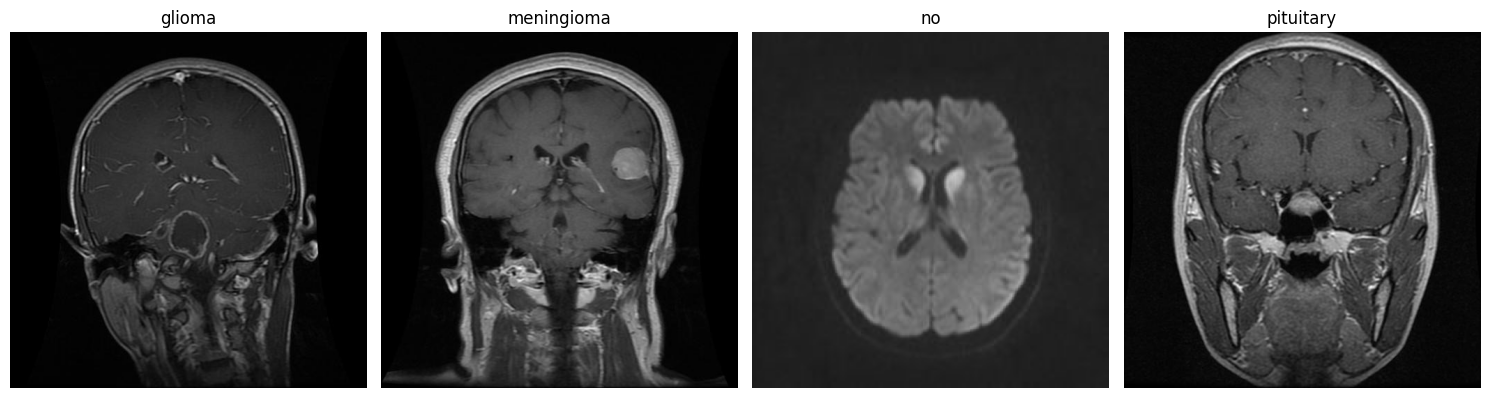

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def plot_random_images_per_class(base_path, class_names):
    plt.figure(figsize=(15, 5))
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(base_path, class_name)
        images = os.listdir(class_path)
        if images:
            random_image_name = random.choice(images)
            random_image_path = os.path.join(class_path, random_image_name)

            img = Image.open(random_image_path)
            plt.subplot(1, len(class_names), i + 1)
            plt.imshow(img)
            plt.title(class_name.replace('_tumor', ''))
            plt.axis('off')
        else:
            print(f"No images found for class: {class_name}")
    plt.tight_layout()
    plt.show()

training_data_path = "/content/brain-tumor-mri-dataset/brain_tumor_dataset/brain_tumor_classification/Training"
plot_random_images_per_class(training_data_path, class_name)

**DATA PREPROCESSING**

In [43]:
train_dataset = datasets.ImageFolder(
    root = "/content/brain-tumor-mri-dataset/brain_tumor_dataset/brain_tumor_classification/Training",
    transform = None
)

In [44]:
test_dataset = datasets.ImageFolder(
    root = "/content/brain-tumor-mri-dataset/brain_tumor_dataset/brain_tumor_classification/Testing",
    transform = None
)

In [45]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, ConcatDataset
import numpy as np

#getting labels
train_targets = train_dataset.targets

#split 80 and 20 percent
train_idx, train_idx_aug = train_test_split(
    np.arange(len(train_targets)),
    test_size=0.2,
    stratify=train_targets,
    random_state=42
)

#creating subset
training_data = Subset(train_dataset, train_idx)
training_data_aug = Subset(train_dataset, train_idx_aug)

#labels for 80%
targets = [train_targets[i] for i in train_idx]

#split that 80% into test and val
final_train_idx, final_val_idx = train_test_split(
    np.arange(len(training_data)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_data = Subset(training_data, final_train_idx)
val_data   = Subset(training_data, final_val_idx)

#explanding test dataset
test_data = ConcatDataset([test_dataset, training_data_aug])

In [46]:
print(f"New Training Data Length: {len(train_data)}")
print(f"New Validation Data Length: {len(val_data)}")
print(f"New Test Data Length: {len(test_data)}")

New Training Data Length: 1836
New Validation Data Length: 460
New Test Data Length: 968


In [47]:
from collections import Counter

original_train_targets = train_dataset.targets

# Train labels
train_labels_current_indices = [train_idx[i] for i in final_train_idx]
new_train_labels = [original_train_targets[i] for i in train_labels_current_indices]

# Validation labels
val_labels_current_indices = [train_idx[i] for i in final_val_idx]
new_val_labels = [original_train_targets[i] for i in val_labels_current_indices]

print("New Train class distribution:", Counter(new_train_labels))
print("New Val class distribution:", Counter(new_val_labels))

New Train class distribution: Counter({0: 529, 3: 529, 1: 525, 2: 253})
New Val class distribution: Counter({3: 133, 0: 132, 1: 132, 2: 63})


In [48]:
from collections import Counter

class_names = train_dataset.classes

# Get labels for new train_data
original_train_targets = train_dataset.targets
train_labels_current_indices = [train_idx[i] for i in final_train_idx]
new_train_labels = [original_train_targets[i] for i in train_labels_current_indices]

train_count = Counter(new_train_labels)

print("New Training Set Class Distribution:")
for idx, count in train_count.items():
    print(f"{class_names[idx]}: {count}")

New Training Set Class Distribution:
glioma_tumor: 529
no_tumor: 253
pituitary_tumor: 529
meningioma_tumor: 525


In [49]:
from collections import Counter

class_names = train_dataset.classes

# Get labels for new val_data
original_train_targets = train_dataset.targets
val_labels_current_indices = [train_idx[i] for i in final_val_idx]
new_val_labels = [original_train_targets[i] for i in val_labels_current_indices]

val_count = Counter(new_val_labels)

print("New Validation Set Class Distribution:")
for idx, count in val_count.items():
    print(f"{class_names[idx]}: {count}")

New Validation Set Class Distribution:
pituitary_tumor: 133
glioma_tumor: 132
meningioma_tumor: 132
no_tumor: 63


In [50]:

class TransformSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]

        if self.transform:
            x = self.transform(x)

        return x, y

In [51]:
augmentation_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),   # very important
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [52]:
train_transform = transforms.Compose([ #only transforms all the images
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])


In [53]:
test_transform = transforms.Compose([ #only transforms all the images
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])


In [54]:
val_transform = transforms.Compose([ #only transforms all the images
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])


In [55]:
train_data_transformed = TransformSubset(train_data, transform=train_transform)
val_data_transformed   = TransformSubset(val_data, transform=val_transform)
test_data_transformed  = TransformSubset(test_data, transform=test_transform)
augmented_data_for_concat = TransformSubset(training_data_aug, transform=augmentation_transform)

In [56]:
train_dataset = train_data_transformed
val_dataset = val_data_transformed
test_dataset = test_data_transformed
augmented_dataset = augmented_data_for_concat

In [57]:
train_dataset = torch.utils.data.ConcatDataset([train_dataset, augmented_dataset])

In [58]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

2410
460
968


In [62]:
x, y = train_dataset[0]
print(type(x))

<class 'torch.Tensor'>


In [70]:
LR = 1e-3 #1e-3
BATCH_SIZE = 8
EPOCHS = 10 #10

**MODEL**

In [71]:
googlenet_model = models.googlenet(weights = 'DEFAULT')

In [72]:
for param in googlenet_model.parameters():
  param.requires_grad = True

In [73]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [74]:
num_classes = len(np.unique(new_train_labels))
print(num_classes)

4


In [75]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features,num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=4, bias=True)

In [76]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

**TRAINING AND VALIDATION**

In [77]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

total_loss_train_plot = []
total_acc_train_plot = []
total_loss_validation_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):

    googlenet_model.train()

    total_loss_train = 0
    total_acc_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()

        outputs = googlenet_model(images)

        if isinstance(outputs, tuple):
            main_out, aux1, aux2 = outputs

            loss1 = loss_fun(main_out, labels)
            loss2 = loss_fun(aux1, labels)
            loss3 = loss_fun(aux2, labels)

            loss = loss1 + 0.3 * loss2 + 0.3 * loss3
            preds = main_out
        else:
            loss = loss_fun(outputs, labels)
            preds = outputs

        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()
        total_acc_train += (torch.argmax(preds, dim=1) == labels).sum().item()

    total_loss_train_plot.append(round(total_loss_train / len(train_loader), 4))
    total_acc_train_plot.append(round(total_acc_train / len(train_loader.dataset) * 100, 4))


    googlenet_model.eval()

    total_loss_val = 0
    total_acc_val = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).long()

            outputs = googlenet_model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = loss_fun(outputs, labels)

            total_loss_val += loss.item()
            total_acc_val += (torch.argmax(outputs, dim=1) == labels).sum().item()

    total_loss_validation_plot.append(round(total_loss_val / len(val_loader), 4))
    total_acc_validation_plot.append(round(total_acc_val / len(val_loader.dataset) * 100, 4))


    print(f'Epoch {epoch+1}/{EPOCHS}')
    print(f'Train Loss: {round(total_loss_train/len(train_loader), 4)} | Train Accuracy: {round(total_acc_train/len(train_loader.dataset)*100, 4)}%')
    print(f'Val Loss: {round(total_loss_val/len(val_loader), 4)} | Val Accuracy: {round(total_acc_val/len(val_loader.dataset)*100, 4)}%\n')

Epoch 1/10
Train Loss: 0.8318 | Train Accuracy: 68.1743%
Val Loss: 0.7728 | Val Accuracy: 71.9565%

Epoch 2/10
Train Loss: 0.5987 | Train Accuracy: 77.9668%
Val Loss: 0.3611 | Val Accuracy: 87.8261%

Epoch 3/10
Train Loss: 0.5081 | Train Accuracy: 81.1203%
Val Loss: 0.2974 | Val Accuracy: 87.8261%

Epoch 4/10
Train Loss: 0.4162 | Train Accuracy: 85.6846%
Val Loss: 0.2232 | Val Accuracy: 93.6957%

Epoch 5/10
Train Loss: 0.3595 | Train Accuracy: 87.5519%
Val Loss: 0.1826 | Val Accuracy: 93.4783%

Epoch 6/10
Train Loss: 0.3449 | Train Accuracy: 87.6763%
Val Loss: 0.239 | Val Accuracy: 91.7391%

Epoch 7/10
Train Loss: 0.3238 | Train Accuracy: 88.5062%
Val Loss: 0.3184 | Val Accuracy: 88.4783%

Epoch 8/10
Train Loss: 0.2805 | Train Accuracy: 89.5851%
Val Loss: 0.2097 | Val Accuracy: 94.3478%

Epoch 9/10
Train Loss: 0.288 | Train Accuracy: 90.083%
Val Loss: 0.3541 | Val Accuracy: 90.8696%

Epoch 10/10
Train Loss: 0.2417 | Train Accuracy: 91.9502%
Val Loss: 0.1491 | Val Accuracy: 95.6522%



In [78]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

# Create DataLoaders for training and validation datasets
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
googlenet_model.eval()

total_acc_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).long()

        outputs = googlenet_model(images)

        if isinstance(outputs, tuple):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)
        total_acc_test += (preds == labels).sum().item()

test_acc = (total_acc_test / len(test_loader.dataset)) * 100

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 86.67%


train acc = 86.67 highest with googlenet 1e-3 and 10 epochs






In [79]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 80.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=14c83a972fba98f133075997e889b140366a1d43907dea268a9fa619d2003dca
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [83]:
import torch
import cv2
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt


googlenet_model.eval()

target_layers = [googlenet_model.inception5b]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def run_grad_cam(image_path):
    rgb_img = cv2.imread(image_path)[:, :, ::-1] # BGR to RGB
    rgb_img = np.float32(cv2.resize(rgb_img, (224, 224))) / 255
    input_tensor = transform(Image.open(image_path)).unsqueeze(0)

    cam = GradCAM(model=googlenet_model, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0, :]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.imshow(visualization)
    plt.axis('off')
    plt.title('Grad-CAM Visualization')
    plt.show()

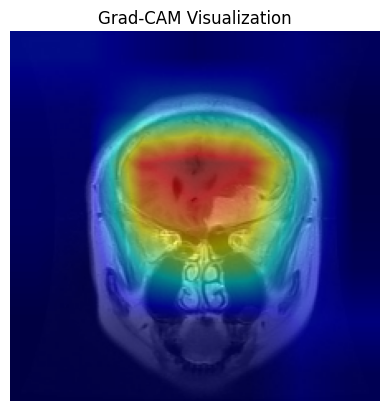

In [84]:
run_grad_cam("/content/brain-tumor-mri-dataset/brain_tumor_dataset/brain_tumor_classification/Training/meningioma_tumor/m (10).jpg")

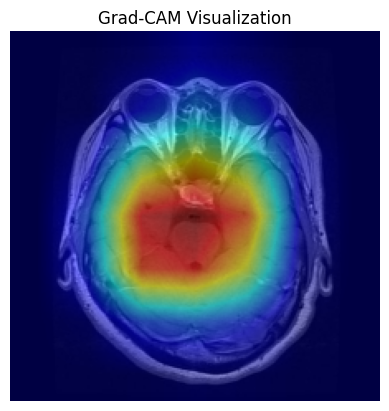

In [86]:
run_grad_cam("/content/brain-tumor-mri-dataset/brain_tumor_dataset/brain_tumor_segmentation/train/images/Tr-piTr_0000_jpg.rf.a5fdc4ac03409741b9de345b7f578ad0.jpg")